In [13]:
import pandas as pd
from pathlib import Path
import os

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Set professional style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'grid.alpha': 0.3
})

# Define color palettes
colors_age = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
colors_tfr = ['#2E86AB', '#A23B72']  # Blue and pink for TFR comparisons
colors_children = ['#FFD700', '#FF8C00', '#DC143C', '#4169E1', '#32CD32']  # Gold, Orange, Crimson, Blue, Lime


In [15]:
barnefordeling_path = Path("data_barnefordeling")

In [16]:
files_kvinnen = sorted([file for file in os.listdir(barnefordeling_path) if file.endswith("Kvinnen.csv")])
files_mannen = sorted([file for file in os.listdir(barnefordeling_path) if file.endswith("Mannen.csv")])


In [17]:
files_begge = sorted([file for file in os.listdir(barnefordeling_path) if file.endswith(".csv")])
files_begge

['20_Kvinnen.csv',
 '20_Mannen.csv',
 '25_Kvinnen.csv',
 '25_Mannen.csv',
 '30_Kvinnen.csv',
 '30_Mannen.csv',
 '35_Kvinnen.csv',
 '35_Mannen.csv',
 '40_Kvinnen.csv',
 '40_Mannen.csv',
 '45_Kvinnen.csv',
 '45_Mannen.csv',
 '50_Mannen.csv']

In [18]:
for file in files_begge:
    df = pd.read_csv(barnefordeling_path / file)


In [19]:
df

,årstall,0 barn,1 barn,2 barn,3 barn,4 barn eller flere,gjennomsnittlig barnetall,kjønn,alder
0,1940,13.6,9.8,35.7,26.5,14.4,2.25,Mannen,50
1,1945,13.3,11.5,40.4,24.3,10.5,2.12,Mannen,50
2,1950,14.4,12.3,40.7,22.6,10.0,2.06,Mannen,50
3,1955,16.6,13.2,37.1,23.3,9.9,2.01,Mannen,50
4,1960,19.9,13.0,34.2,23.0,9.9,1.95,Mannen,50
5,1965,22.0,13.9,34.2,21.2,8.7,1.84,Mannen,50
6,1970,22.4,14.5,35.5,19.8,7.7,1.80,Mannen,50
7,1974,23.6,14.6,36.0,18.9,6.9,1.74,Mannen,50


In [20]:
df["kjønn"].unique()[0] + " " + str(df["alder"].unique()[0])

'Mannen 50'

In [21]:
df_full = pd.DataFrame({"årstall" :list(range(1935, 2004, 5)) + [2004] })
df_full

,årstall
0,1935
1,1940
2,1945
3,1950
4,1955
5,1960
6,1965
7,1970
8,1975
9,1980


In [22]:
pd.read_csv(barnefordeling_path / files_mannen[0])

,årstall,0 barn,1 barn,2 barn,3 barn,4 barn eller flere,gjennomsnittlig barnetall,kjønn,alder
0,1940,95.3,4.3,0.4,0.0,0.0,0.05,Mannen,20
1,1945,94.1,5.3,0.6,0.0,0.0,0.07,Mannen,20
2,1950,93.5,5.8,0.6,0.0,0.0,0.07,Mannen,20
3,1955,94.0,5.8,0.3,0.0,0.0,0.06,Mannen,20
4,1960,96.9,3.0,0.1,0.0,0.0,0.03,Mannen,20
5,1965,97.6,2.4,0.1,0.0,0.0,0.03,Mannen,20
6,1970,97.6,2.3,0.1,0.0,0.0,0.03,Mannen,20
7,1975,98.2,1.7,0.1,0.0,0.0,0.02,Mannen,20
8,1980,98.2,1.7,0.1,0.0,0.0,0.02,Mannen,20
9,1985,98.7,1.2,0.1,0.0,0.0,0.01,Mannen,20


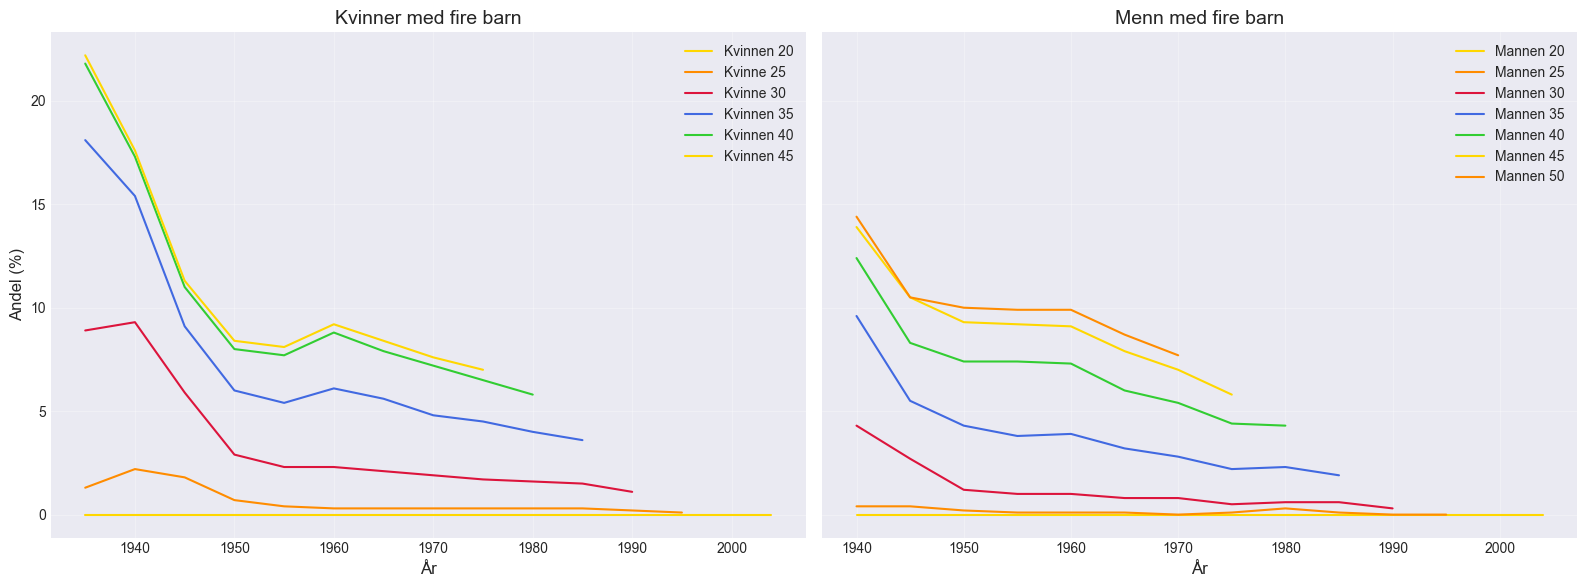

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
col = "4 barn eller flere"

for ax, files, title in zip(axes, [files_kvinnen, files_mannen], ["Kvinner med fire barn", "Menn med fire barn"]):
    df_full = pd.DataFrame({"årstall": list(range(1935, 2004, 5)) + [2004]})
    for file in files:
        df = pd.read_csv(barnefordeling_path / file)
        df_subset = df[["årstall", col]].copy()
        df_subset.columns = ["årstall", f"{df['kjønn'].unique()[0]} {df['alder'].unique()[0]}"]
        df_full = df_full.merge(df_subset, on="årstall", how="left")
    df_full.plot(x="årstall", ax=ax, title=title, color=colors_children[:len(df_full.columns)-1])
    ax.set_ylabel('Andel (%)')
    ax.set_xlabel('År')

plt.tight_layout()


Text(0.5, 1.0, 'Andel kvinner med 3 barn')

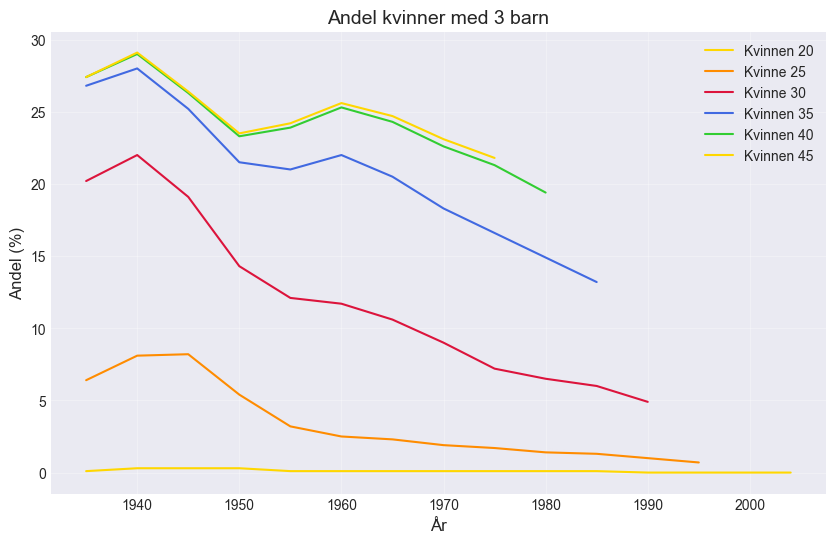

In [24]:
df_full = pd.DataFrame({"årstall" :list(range(1935, 2004, 5)) + [2004] })
col = "3 barn"
for file in files_kvinnen:
    df = pd.read_csv(barnefordeling_path / file)
    df_fire_barn = df[["årstall",col]]
    df_fire_barn.columns = ["årstall", df["kjønn"].unique()[0] + " " + str(df["alder"].unique()[0])]
    df_full = df_full.merge(df_fire_barn, on ="årstall", how="left") 
ax = df_full.plot(x="årstall", color=colors_children[:len(df_full.columns)-1], figsize=(10, 6))
ax.set_ylabel('Andel (%)')
ax.set_xlabel('År')
ax.set_title('Andel kvinner med 3 barn')


Text(0.5, 1.0, 'Andel kvinner med 2 barn')

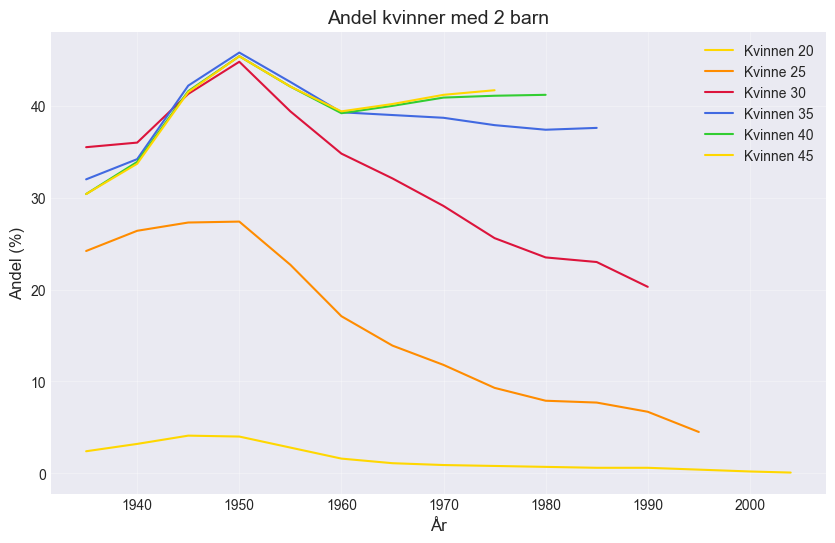

In [25]:
df_full = pd.DataFrame({"årstall" :list(range(1935, 2004, 5)) + [2004] })
col = "2 barn"
for file in files_kvinnen:
    df = pd.read_csv(barnefordeling_path / file)
    df_fire_barn = df[["årstall",col]]
    df_fire_barn.columns = ["årstall", df["kjønn"].unique()[0] + " " + str(df["alder"].unique()[0])]
    df_full = df_full.merge(df_fire_barn, on ="årstall", how="left") 
ax = df_full.plot(x="årstall", color=colors_children[:len(df_full.columns)-1], figsize=(10, 6))
ax.set_ylabel('Andel (%)')
ax.set_xlabel('År')
ax.set_title('Andel kvinner med 2 barn')


Text(0.5, 1.0, 'Andel med 1 barn')

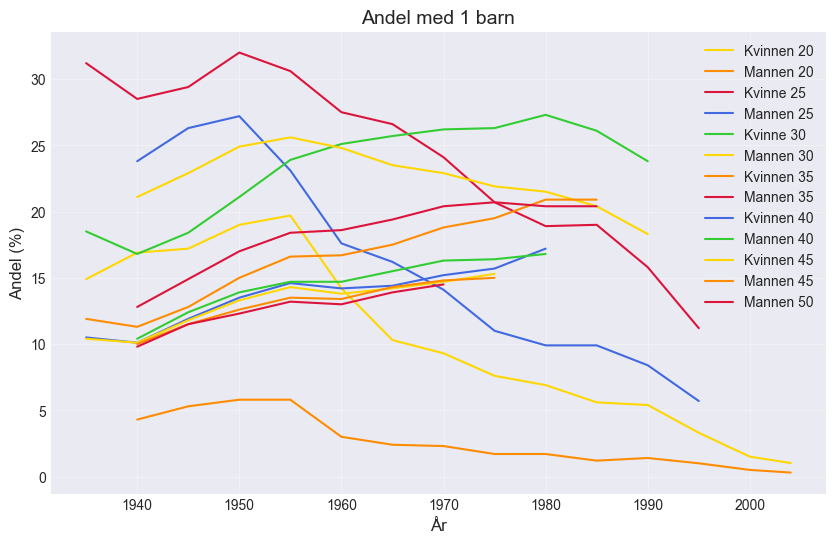

In [26]:
df_full = pd.DataFrame({"årstall" :list(range(1935, 2004, 5)) + [2004] })
col = "1 barn"
for file in files_begge:
    df = pd.read_csv(barnefordeling_path / file)
    df_fire_barn = df[["årstall",col]]
    df_fire_barn.columns = ["årstall", df["kjønn"].unique()[0] + " " + str(df["alder"].unique()[0])]
    df_full = df_full.merge(df_fire_barn, on ="årstall", how="left") 
ax = df_full.plot(x="årstall", color=colors_children[:len(df_full.columns)-1], figsize=(10, 6))
ax.set_ylabel('Andel (%)')
ax.set_xlabel('År')
ax.set_title('Andel med 1 barn')


Text(0.5, 1.0, 'Andel kvinner uten barn')

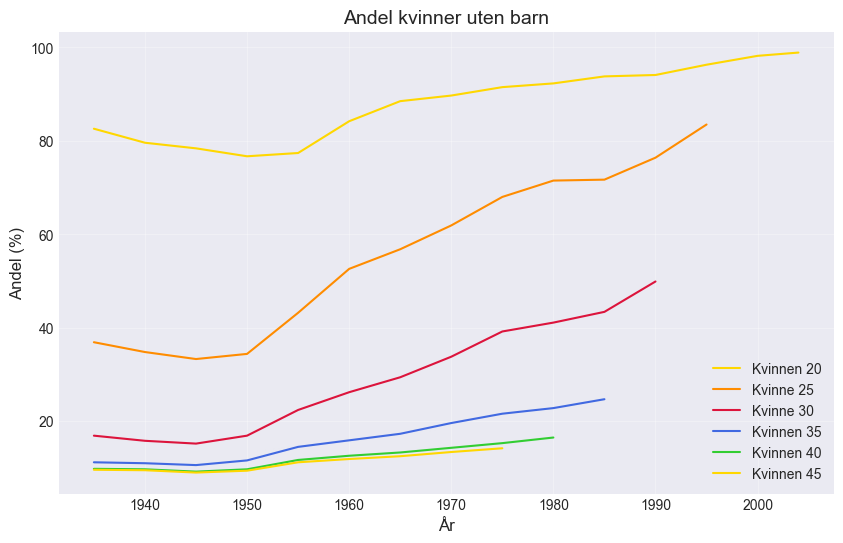

In [27]:
df_full = pd.DataFrame({"årstall" :list(range(1935, 2004, 5)) + [2004] })
col = "0 barn"
for file in files_kvinnen:
    df = pd.read_csv(barnefordeling_path / file)
    df_fire_barn = df[["årstall",col]]
    df_fire_barn.columns = ["årstall", df["kjønn"].unique()[0] + " " + str(df["alder"].unique()[0])]
    df_full = df_full.merge(df_fire_barn, on ="årstall", how="left") 
ax = df_full.plot(x="årstall", color=colors_children[:len(df_full.columns)-1], figsize=(10, 6))
ax.set_ylabel('Andel (%)')
ax.set_xlabel('År')
ax.set_title('Andel kvinner uten barn')


Text(0.5, 1.0, 'Gjennomsnittlig barnetall per kvinne')

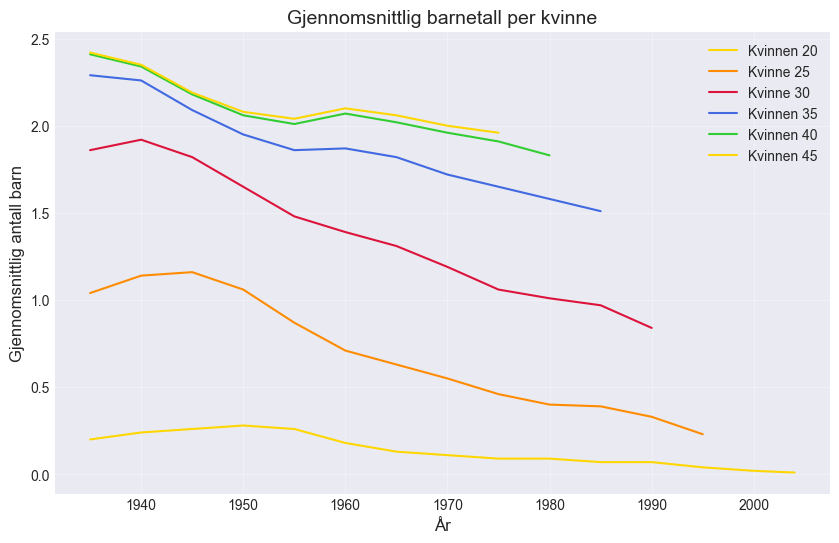

In [28]:
df_full = pd.DataFrame({"årstall" :list(range(1935, 2004, 5)) + [2004] })
col = "gjennomsnittlig barnetall"
for file in files_kvinnen:
    df = pd.read_csv(barnefordeling_path / file)
    df_fire_barn = df[["årstall",col]]
    df_fire_barn.columns = ["årstall", df["kjønn"].unique()[0] + " " + str(df["alder"].unique()[0])]
    df_full = df_full.merge(df_fire_barn, on ="årstall", how="left") 
ax = df_full.plot(x="årstall", color=colors_children[:len(df_full.columns)-1], figsize=(10, 6))
ax.set_ylabel('Gjennomsnittlig antall barn')
ax.set_xlabel('År')
ax.set_title('Gjennomsnittlig barnetall per kvinne')


In [29]:
kvinnen = pd.read_csv(barnefordeling_path / files_kvinnen[0])
kvinnen["0 barn"] / kvinnen["0 barn"][0] 


0     1.000000
1     0.963680
2     0.949153
3     0.928571
4     0.937046
5     1.019370
6     1.071429
7     1.085956
8     1.107748
9     1.117433
10    1.135593
11    1.139225
12    1.165860
13    1.188862
14    1.197337
Name: 0 barn, dtype: float64

Text(0.5, 1.0, 'Andel kvinner (40 år) per antall barn')

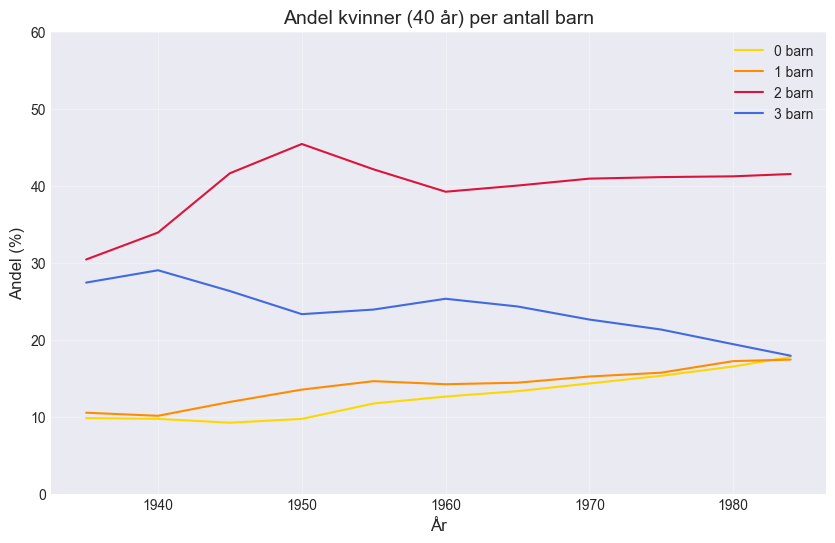

In [30]:
kvinne = pd.read_csv(barnefordeling_path / "40_Kvinnen.csv")
ax = kvinne.plot(x="årstall", y=kvinne.columns[1:5], ylim=(0, 60), color=colors_children[:4], figsize=(10, 6))
ax.set_ylabel('Andel (%)')
ax.set_xlabel('År')
ax.set_title('Andel kvinner (40 år) per antall barn')


In [31]:
kvinne

,årstall,0 barn,1 barn,2 barn,3 barn,4 barn eller flere,gjennomsnittlig barnetall,kjønn,alder
0,1935,9.80,10.5,30.4,27.4,21.80,2.41,Kvinnen,40
1,1940,9.70,10.1,33.9,29.0,17.30,2.34,Kvinnen,40
2,1945,9.20,11.9,41.6,26.3,11.00,2.18,Kvinnen,40
3,1950,9.70,13.5,45.4,23.3,8.00,2.06,Kvinnen,40
4,1955,11.70,14.6,42.1,23.9,7.70,2.01,Kvinnen,40
5,1960,12.60,14.2,39.2,25.3,8.80,2.07,Kvinnen,40
6,1965,13.30,14.4,40.0,24.3,7.90,2.02,Kvinnen,40
7,1970,14.30,15.2,40.9,22.6,7.20,1.96,Kvinnen,40
8,1975,15.30,15.7,41.1,21.3,6.50,1.91,Kvinnen,40
9,1980,16.50,17.2,41.2,19.4,5.80,1.83,Kvinnen,40


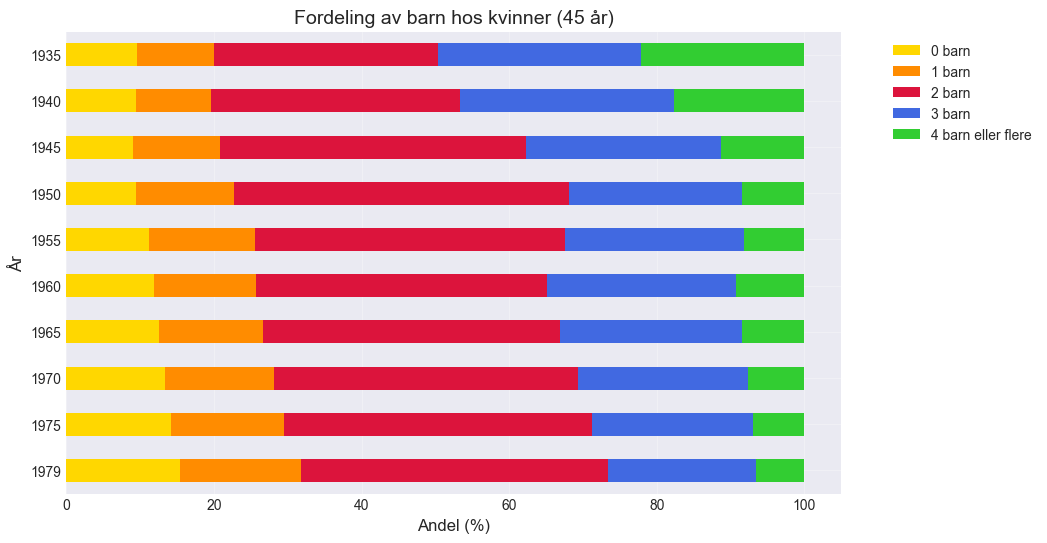

In [43]:
kvinne = pd.read_csv(barnefordeling_path / "45_Kvinnen.csv").sort_values("årstall", ascending=False)
ax = kvinne.plot(x="årstall", y=kvinne.columns[1:6], kind="barh", stacked=True, ylim=(0, 100), color=colors_children, figsize=(10, 6))
ax.set_xlabel('Andel (%)')
ax.set_ylabel('År')
ax.set_title('Fordeling av barn hos kvinner (45 år)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


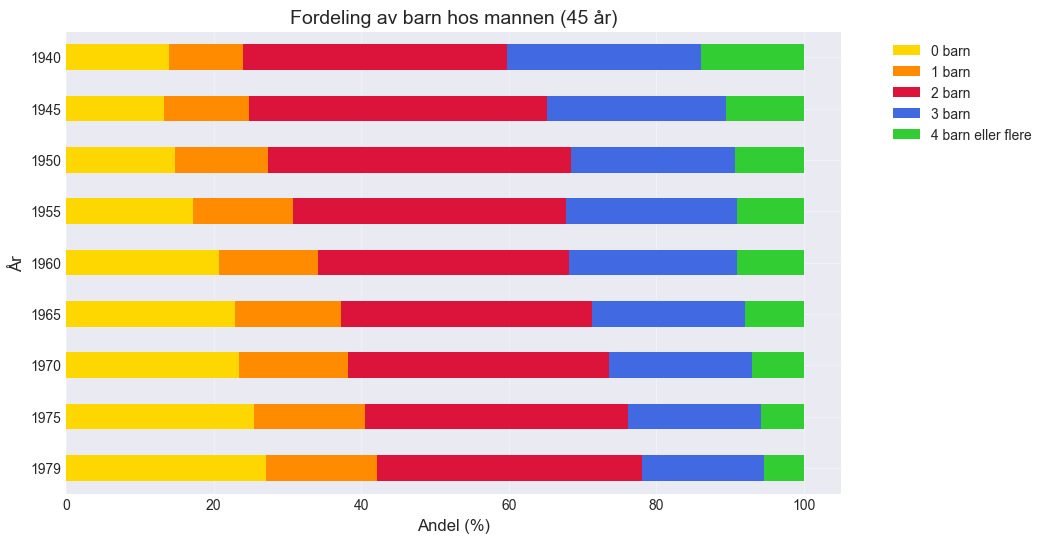

In [49]:
kvinne = pd.read_csv(barnefordeling_path / "45_Mannen.csv").sort_values("årstall", ascending=False)
ax = kvinne.plot(x="årstall", y=kvinne.columns[1:6], kind="barh", stacked=True, ylim=(0, 100), color=colors_children, figsize=(10, 6))
ax.set_xlabel('Andel (%)')
ax.set_ylabel('År')
ax.set_title('Fordeling av barn hos mannen (45 år)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


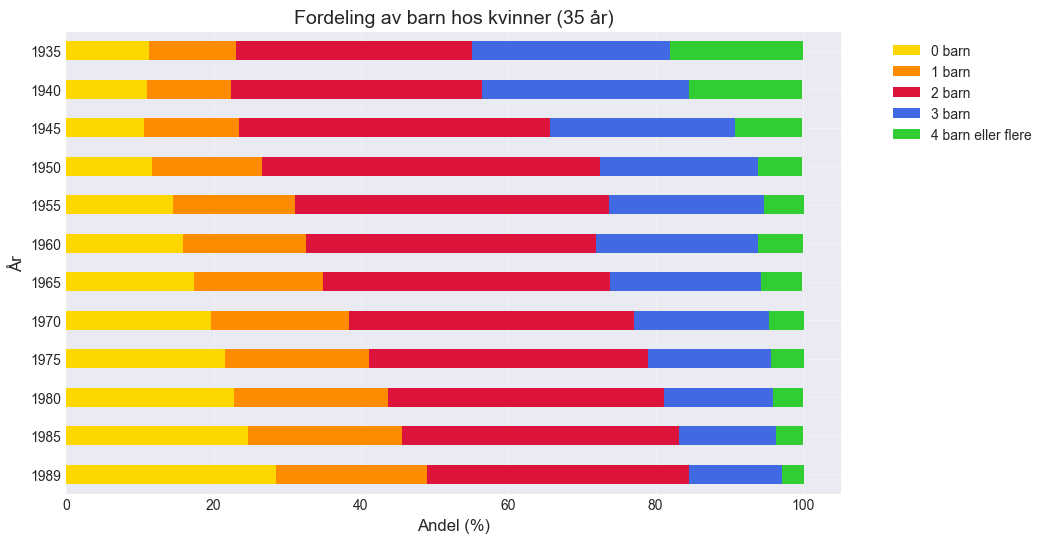

In [42]:
kvinne = pd.read_csv(barnefordeling_path / "35_Kvinnen.csv").sort_values("årstall", ascending=False)
ax = kvinne.plot(x="årstall", y=kvinne.columns[1:6], kind="barh", stacked=True, ylim=(0, 100), color=colors_children, figsize=(10, 6))
ax.set_xlabel('Andel (%)')
ax.set_ylabel('År')
ax.set_title('Fordeling av barn hos kvinner (35 år)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


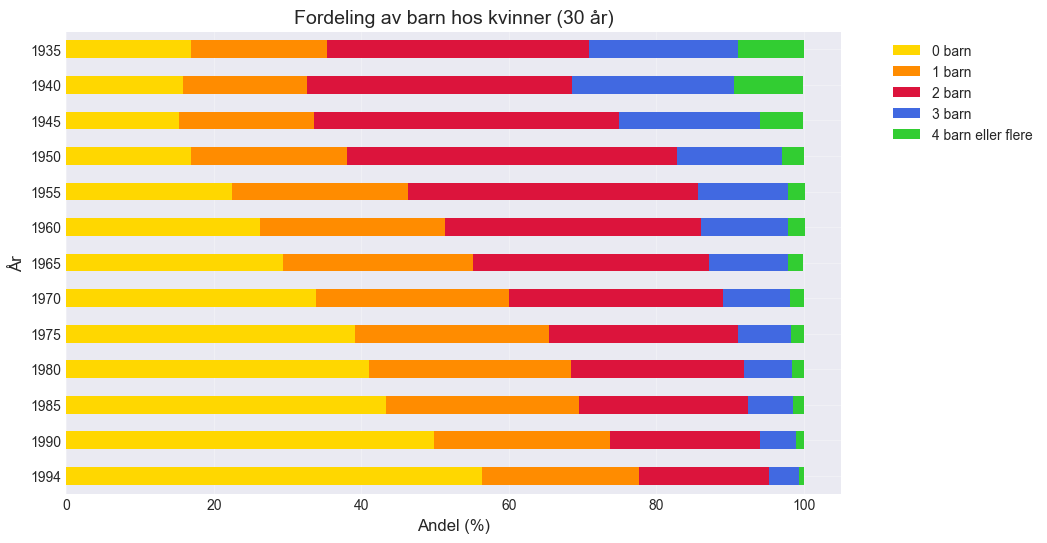

In [34]:
kvinne = pd.read_csv(barnefordeling_path / "30_Kvinnen.csv").sort_values("årstall", ascending=False)
ax = kvinne.plot(x="årstall", y=kvinne.columns[1:6], kind="barh", stacked=True, ylim=(0, 100), color=colors_children, figsize=(10, 6))
ax.set_xlabel('Andel (%)')
ax.set_ylabel('År')
ax.set_title('Fordeling av barn hos kvinner (30 år)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


Text(0.5, 1.0, 'Endring i andel per antall barn for kvinner (45 år)')

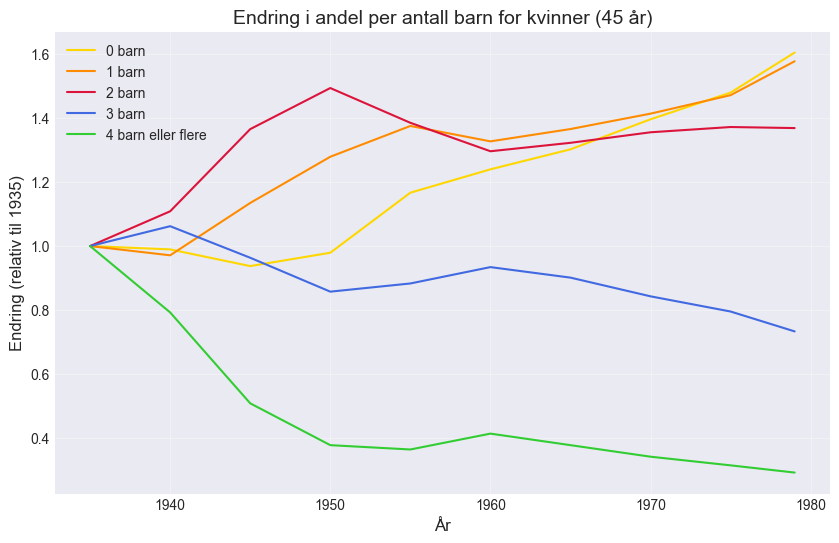

In [ ]:
kvinne = pd.read_csv(barnefordeling_path / "45_Kvinnen.csv").sort_values("årstall", ascending=True).reset_index(drop=True)
kvinne

df_change_in_birth = pd.DataFrame(kvinne["årstall"])

colomos = ['0 barn', '1 barn', '2 barn', '3 barn', '4 barn eller flere']
for col in colomos:
    df_change_in_birth[col] = kvinne[col] / kvinne[col][0]

ax = df_change_in_birth.plot(x="årstall", color=colors_children, figsize=(10, 6))
ax.set_ylabel('Endring (relativ til 1935)')
ax.set_xlabel('År')
ax.set_title('Endring i andel per antall barn for kvinner (45 år)')


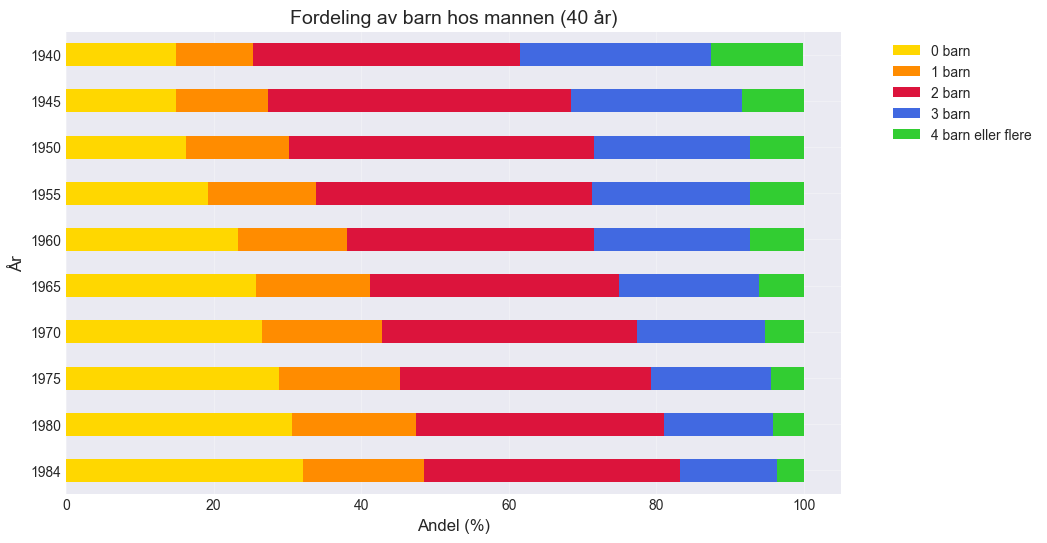

In [59]:
alder = 40

kvinne = pd.read_csv(barnefordeling_path / f"{alder}_Mannen.csv").sort_values("årstall", ascending=False)
ax = kvinne.plot(x="årstall", y=kvinne.columns[1:6], kind="barh", stacked=True, ylim=(0, 100), color=colors_children, figsize=(10, 6))
ax.set_xlabel('Andel (%)')
ax.set_ylabel('År')
ax.set_title(f'Fordeling av barn hos mannen ({alder} år)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


Text(0.5, 1.0, 'Endring i andel per antall barn for menn (35 år)')

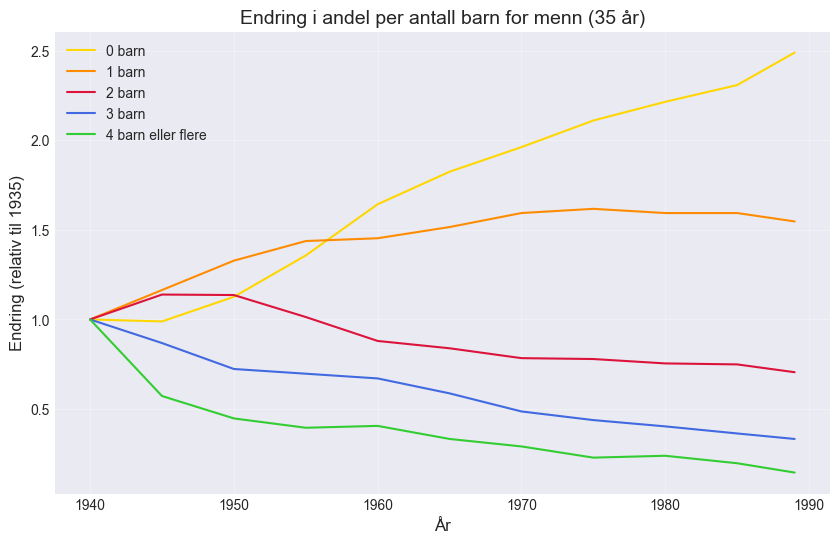

In [61]:
alder = 35
kvinne = pd.read_csv(barnefordeling_path / f"{alder}_Mannen.csv").sort_values("årstall", ascending=True).reset_index(drop=True)
kvinne

df_change_in_birth = pd.DataFrame(kvinne["årstall"])

colomos = ['0 barn', '1 barn', '2 barn', '3 barn', '4 barn eller flere']
for col in colomos:
    df_change_in_birth[col] = kvinne[col] / kvinne[col][0]

ax = df_change_in_birth.plot(x="årstall", color=colors_children, figsize=(10, 6))
ax.set_ylabel('Endring (relativ til 1935)')
ax.set_xlabel('År')
ax.set_title(f'Endring i andel per antall barn for menn ({alder} år)')


In [38]:
df

,årstall,0 barn,1 barn,2 barn,3 barn,4 barn eller flere,gjennomsnittlig barnetall,kjønn,alder
0,1935,9.6,10.4,30.4,27.4,22.2,2.42,Kvinnen,45
1,1940,9.5,10.1,33.7,29.1,17.6,2.35,Kvinnen,45
2,1945,9.0,11.8,41.5,26.4,11.3,2.19,Kvinnen,45
3,1950,9.4,13.3,45.4,23.5,8.4,2.08,Kvinnen,45
4,1955,11.2,14.3,42.1,24.2,8.1,2.04,Kvinnen,45
5,1960,11.9,13.8,39.4,25.6,9.2,2.10,Kvinnen,45
6,1965,12.5,14.2,40.2,24.7,8.4,2.06,Kvinnen,45
7,1970,13.4,14.7,41.2,23.1,7.6,2.00,Kvinnen,45
8,1975,14.2,15.3,41.7,21.8,7.0,1.96,Kvinnen,45
9,1979,15.4,16.4,41.6,20.1,6.5,1.89,Kvinnen,45


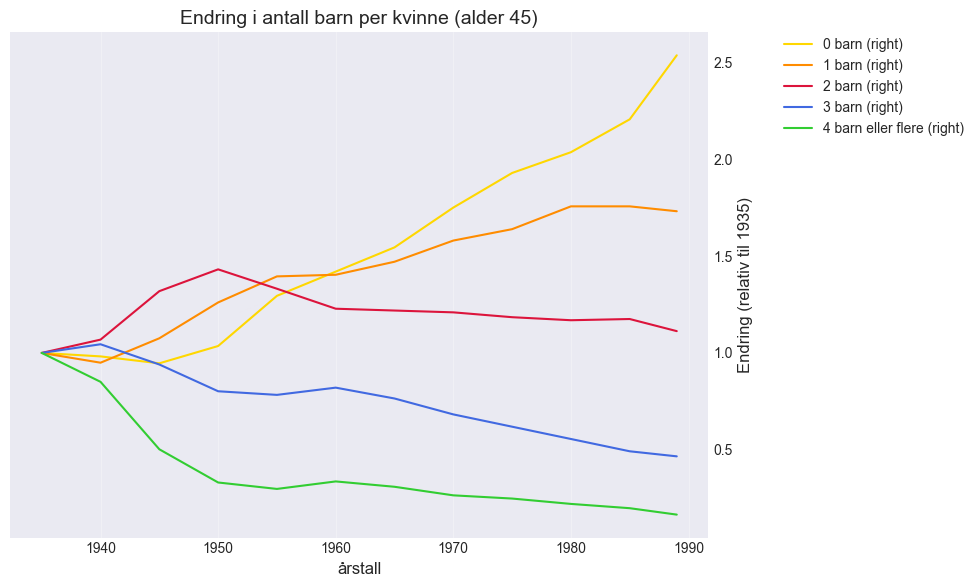

In [39]:
import matplotlib.pyplot as plt

# 1. Prepare data (same as before)
kolonner = ['0 barn', '1 barn', '2 barn', '3 barn', '4 barn eller flere']
for col in kolonner:
    df_change_in_birth[col] = kvinne[col] / kvinne[col].iloc[0]

# 2. Plot with defined colors
ax = df_change_in_birth.plot(
    x="årstall", 
    secondary_y=kolonner, 
    title=f"Endring i antall barn per kvinne (alder {df['alder'].unique()[0]})",
    figsize=(10, 6),
    legend=False,
    color=colors_children
)

# 3. Handle the legend
ax.set_ylabel('Endring (relativ til 1935)')
ax.legend(loc="upper left", bbox_to_anchor=(1.1, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()


In [66]:
df

,årstall,0 barn,1 barn,2 barn,3 barn,4 barn eller flere,gjennomsnittlig barnetall,kjønn,alder
0,1935,9.6,10.4,30.4,27.4,22.2,2.42,Kvinnen,45
1,1940,9.5,10.1,33.7,29.1,17.6,2.35,Kvinnen,45
2,1945,9.0,11.8,41.5,26.4,11.3,2.19,Kvinnen,45
3,1950,9.4,13.3,45.4,23.5,8.4,2.08,Kvinnen,45
4,1955,11.2,14.3,42.1,24.2,8.1,2.04,Kvinnen,45
5,1960,11.9,13.8,39.4,25.6,9.2,2.10,Kvinnen,45
6,1965,12.5,14.2,40.2,24.7,8.4,2.06,Kvinnen,45
7,1970,13.4,14.7,41.2,23.1,7.6,2.00,Kvinnen,45
8,1975,14.2,15.3,41.7,21.8,7.0,1.96,Kvinnen,45
9,1979,15.4,16.4,41.6,20.1,6.5,1.89,Kvinnen,45


In [60]:
kvinne

,årstall,0 barn,1 barn,2 barn,3 barn,4 barn eller flere,gjennomsnittlig barnetall,kjønn,alder
0,1935,9.80,10.5,30.4,27.4,21.80,2.41,Kvinnen,40
1,1940,9.70,10.1,33.9,29.0,17.30,2.34,Kvinnen,40
2,1945,9.20,11.9,41.6,26.3,11.00,2.18,Kvinnen,40
3,1950,9.70,13.5,45.4,23.3,8.00,2.06,Kvinnen,40
4,1955,11.70,14.6,42.1,23.9,7.70,2.01,Kvinnen,40
5,1960,12.60,14.2,39.2,25.3,8.80,2.07,Kvinnen,40
6,1965,13.30,14.4,40.0,24.3,7.90,2.02,Kvinnen,40
7,1970,14.30,15.2,40.9,22.6,7.20,1.96,Kvinnen,40
8,1975,15.30,15.7,41.1,21.3,6.50,1.91,Kvinnen,40
9,1980,16.50,17.2,41.2,19.4,5.80,1.83,Kvinnen,40


In [62]:
(0 + 1 + 2 + 3 + 4) / 5

2.0

In [176]:
kvinne = pd.read_csv(barnefordeling_path / "30_Kvinnen.csv").sort_values("årstall", ascending=True).reset_index(drop=True)
totalt_antall_barn = pd.DataFrame(kvinne["årstall"])

totalt_antall_barn["0 barn antall"] = kvinne["0 barn"] * 0
totalt_antall_barn["1 barn antall"] = kvinne["1 barn"] * 1
totalt_antall_barn["2 barn antall"] = kvinne["2 barn"] * 2
totalt_antall_barn["3 barn antall"] = kvinne["3 barn"] * 3
totalt_antall_barn["4 barn antall"] = kvinne["4 barn eller flere"] * 4
totalt_antall_barn["sum"] = totalt_antall_barn.iloc[:,1:].sum(axis=1)
totalt_antall_barn["utvikling"] = totalt_antall_barn["sum"] / totalt_antall_barn["sum"][0]
totalt_antall_barn


,årstall,0 barn antall,1 barn antall,2 barn antall,3 barn antall,4 barn antall,sum,utvikling
0,1935,0.0,18.5,71.0,60.6,35.6,185.7,1.000000
1,1940,0.0,16.8,72.0,66.0,37.2,192.0,1.033926
2,1945,0.0,18.4,82.6,57.3,23.6,181.9,0.979537
3,1950,0.0,21.1,89.6,42.9,11.6,165.2,0.889607
4,1955,0.0,23.9,78.8,36.3,9.2,148.2,0.798061
5,1960,0.0,25.1,69.6,35.1,9.2,139.0,0.748519
6,1965,0.0,25.7,64.2,31.8,8.4,130.1,0.700592
7,1970,0.0,26.2,58.2,27.0,7.6,119.0,0.640819
8,1975,0.0,26.3,51.2,21.6,6.8,105.9,0.570275
9,1980,0.0,27.3,47.0,19.5,6.4,100.2,0.539580


In [177]:
kvinne = pd.read_csv(barnefordeling_path / "35_Kvinnen.csv").sort_values("årstall", ascending=True).reset_index(drop=True)
totalt_antall_barn = pd.DataFrame(kvinne["årstall"])

totalt_antall_barn["0 barn antall"] = kvinne["0 barn"] * 0
totalt_antall_barn["1 barn antall"] = kvinne["1 barn"] * 1
totalt_antall_barn["2 barn antall"] = kvinne["2 barn"] * 2
totalt_antall_barn["3 barn antall"] = kvinne["3 barn"] * 3
totalt_antall_barn["4 barn antall"] = kvinne["4 barn eller flere"] * 4
totalt_antall_barn["sum"] = totalt_antall_barn.iloc[:,1:].sum(axis=1)
totalt_antall_barn["utvikling"] = totalt_antall_barn["sum"] / totalt_antall_barn["sum"][0]
totalt_antall_barn


,årstall,0 barn antall,1 barn antall,2 barn antall,3 barn antall,4 barn antall,sum,utvikling
0,1935,0.0,11.9,64.0,80.4,72.4,228.7,1.000000
1,1940,0.0,11.3,68.4,84.0,61.6,225.3,0.985133
2,1945,0.0,12.8,84.4,75.6,36.4,209.2,0.914735
3,1950,0.0,15.0,91.6,64.5,24.0,195.1,0.853083
4,1955,0.0,16.6,85.2,63.0,21.6,186.4,0.815042
5,1960,0.0,16.7,78.6,66.0,24.4,185.7,0.811981
6,1965,0.0,17.5,78.0,61.5,22.4,179.4,0.784434
7,1970,0.0,18.8,77.4,54.9,19.2,170.3,0.744644
8,1975,0.0,19.5,75.8,49.8,18.0,163.1,0.713161
9,1980,0.0,20.9,74.8,44.7,16.0,156.4,0.683865


In [ ]:
x = np.linspace(1,10,10)
df_vekst = pd.DataFrame({"generasjon": x})

antall_barn = [0, 0.5, 1, 1.25, 1.5, 1.7,  2, 3, 4]

for barn in antall_barn:
    df_vekst[f"{barn}"] = np.log((barn/2) ** (x / 2))

ax = df_vekst.plot(x="generasjon", figsize=(10, 6), color=colors_children[:len(antall_barn)])
ax.set_ylabel('Logaritmisk vekst')
ax.set_xlabel('Generasjon')
ax.set_title('Populasjonsvekst etter antall barn')


/var/folders/0k/kjly72p17y1gxqhyj4zvz9yh0000gn/T/ipykernel_66676/2586264814.py:9: RuntimeWarning: divide by zero encountered in log
  df_vekst[f"{barn}"] = np.log((barn/2) ** (x / 2))


<Axes: xlabel='generasjon'>

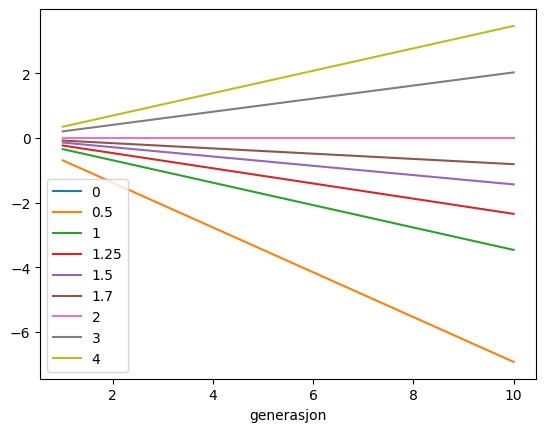

In [ ]:
ax = df_vekst.plot(x="generasjon", figsize=(10, 6), color=colors_children)
ax.set_ylabel('Populasjonsmultiplikator')
ax.set_xlabel('Generasjon')
ax.set_title('Populasjonsvekst')


<Axes: xlabel='Generasjon'>

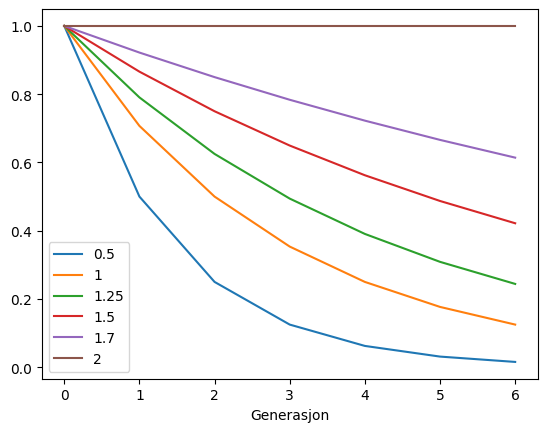

In [ ]:
import numpy as np 

x = np.linspace(0,6,7)
df_vekst = pd.DataFrame({"Generasjon": x})

antall_barn = [0.5, 1, 1.25, 1.5, 1.7,  2]

for barn in antall_barn:
    df_vekst[f"{barn}"] = (barn/2) ** (x / 2)

ax = df_vekst.plot(x="Generasjon", figsize=(10, 6), color=colors_children[:len(antall_barn)])
ax.set_ylabel('Populasjonsmultiplikator')
ax.set_xlabel('Generasjon')
ax.set_title('Populasjonsvekst - modell 1')


<Axes: xlabel='generasjon'>

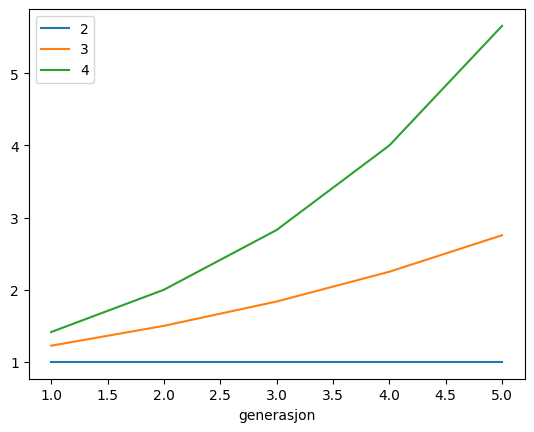

In [ ]:
import numpy as np 

x = np.linspace(1,5,5)
df_vekst = pd.DataFrame({"generasjon": x})

antall_barn = [2, 3, 4]

for barn in antall_barn:
    df_vekst[f"{barn}"] = (barn/2) ** (x / 2)

ax = df_vekst.plot(x="generasjon", figsize=(10, 6), color=colors_children[1:4])
ax.set_ylabel('Populasjonsmultiplikator')
ax.set_xlabel('Generasjon')
ax.set_title('Populasjonsvekst - modell 2')
